# 📖 INTRO

## 🔖 SUMMARY

**This analysis explores the quarterly performance of a Retail Gaming Business over a multi-year period.**

## 📦 DATASET

**✔ Dataset description:**

An anonymized dataset containing **real quarterly sales and commission data** from a retail gaming business *(2017–2023).*

The dataset includes:
- dates
- product categories
- sales performance
- commission efficiency metrics

# 🧱 STEP 1 — Load dataset

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/periklisandrianos/betting-store-small-business-dataset/betting_store_data.csv")
df.head()

,date,game,category,sales,first_commission,final_commission
0,q2-2017,FINO,lottery,104591.5,8367.32,8200.59
1,q2-2017,JACKPOT,lottery,14209.5,1705.14,1894.17
2,q2-2017,LOTO,lottery,1237.0,148.44,178.81
3,q2-2017,SEVEN-IN-ROW,lottery,858.0,102.96,99.13
4,q2-2017,LUCKY-3,lottery,452.5,36.20,41.50


# 🧱 STEP 2 — Check structure

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              550 non-null    object 
 1   game              550 non-null    object 
 2   category          550 non-null    object 
 3   sales             550 non-null    float64
 4   first_commission  550 non-null    float64
 5   final_commission  550 non-null    float64
dtypes: float64(3), object(3)
memory usage: 25.9+ KB


,sales,first_commission,final_commission
count,550.000000,550.000000,550.000000
mean,8531.402727,579.981509,590.789945
std,20726.112857,1487.543287,1501.165792
min,0.000000,0.000000,0.000000
25%,35.375000,3.892500,4.077500
50%,556.875000,42.890000,46.275000
75%,7622.000000,338.977500,370.862500
max,135536.000000,9355.520000,9437.880000


# 🧱 STEP 3 — Fix DATE

In [3]:
def convert_quarter(q):
    quarter, year = q.split("-")
    q_num = int(quarter[1])
    
    month = {1:1, 2:4, 3:7, 4:10}[q_num]
    
    return pd.Timestamp(year=int(year), month=month, day=1)

df["date"] = df["date"].apply(convert_quarter)

# 🧱 STEP 4 — Feature Engineering

In [4]:
df["commission_rate_%"] = (df["final_commission"] / df["sales"]) * 100

df["year"] = df["date"].dt.year
df["quarter"] = df["date"].dt.quarter
df.head()

,date,game,category,sales,first_commission,final_commission,commission_rate_%,year,quarter
0,2017-04-01,FINO,lottery,104591.5,8367.32,8200.59,7.840589,2017,2
1,2017-04-01,JACKPOT,lottery,14209.5,1705.14,1894.17,13.330307,2017,2
2,2017-04-01,LOTO,lottery,1237.0,148.44,178.81,14.455133,2017,2
3,2017-04-01,SEVEN-IN-ROW,lottery,858.0,102.96,99.13,11.553613,2017,2
4,2017-04-01,LUCKY-3,lottery,452.5,36.20,41.50,9.171271,2017,2


# 🧱 STEP 5 — Aggregation

In [5]:
quarterly = df.groupby("date").agg({
    "sales": "sum",
    "final_commission": "sum"
}).reset_index()

# 📊 STEP 6 — First Plot

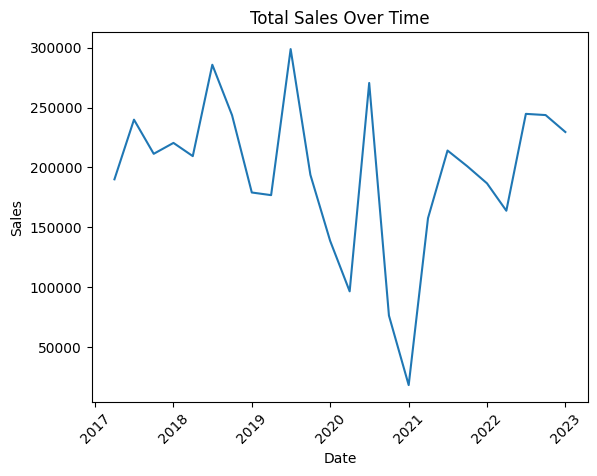

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(quarterly["date"], quarterly["sales"])
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# 💡 STEP 7 - Insights

## 📈 1. Overall Trend

👉 There is no clear long-term growth trend

- 2017–2019: relatively stable period with fluctuations

- 2022–2023: return to high levels

✔ Conclusion:

The business shows cyclical performance and not consistent growth.

## 📉 2. Significant Drop (2020–2021)

👉 This is your strongest observation:

- Huge drop (up to ~20,000)
- Spikes and crashes

✔ Interpretation:

The sharp drop during 2020–2021 is likely linked to COVID-19 restrictions, which significantly affected retail activities.

## 📊 3. Volatility

👉 We see:

- large fluctuations

- not a smooth curve

✔ Conclusion:

Sales show high volatility, indicating dependence on external factors or seasonal demand.

## 🔁 4. Recovery Phase

👉 After 2021:

- strong recovery
- back to 200,000+

✔ Conclusion:

The business demonstrates strong resilience to external shocks.

# 🧱 STEP 8 - Group By Category

In [7]:
df.groupby("category")["sales"].sum().sort_values(ascending=False)

category
lottery     2634227.5
bettting    1075323.5
virtual      982720.5
Name: sales, dtype: float64

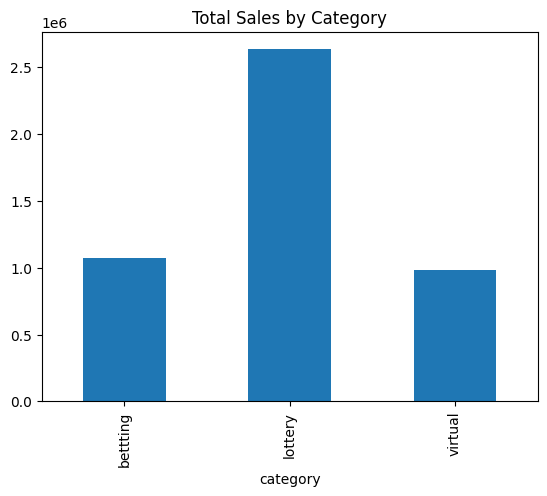

In [8]:
df.groupby("category")["sales"].sum().plot(kind="bar")
plt.title("Total Sales by Category")
plt.show()

## 🟣 CATEGORY INFO

👉 Lottery dominates:

- Lottery ≈ 2.6 million
- Betting ≈ 1.07 million
- Virtual ≈ 0.98 million

✔ Conclusion:

Lottery products are the main revenue driver, contributing to more than 50% of total sales.

# 🧱 STEP 9 - Group by Game

In [9]:
df.groupby("game")["sales"].sum().sort_values(ascending=False)

game
FINO               2180617.00
V-SOCCER_1          542994.75
JACKPOT             359439.00
BET_4               297238.25
BET_1               265433.50
LUCKYSPIN           232168.00
V-SOCCER            167483.25
BET_2               123403.75
BET_3               110907.75
BET PRE_4           107455.50
BET PRE_3            47304.25
LOTO                 34308.00
BET LIVE_1           31732.50
BET PRE_1            29351.75
BET PRE_2            28689.75
V-SOCCER_2           26453.75
FINO SELF            19576.50
SEVEN-IN-ROW         18961.50
BET SELF_1           16807.75
LUCKY-3              14205.00
V-SOCCER_3            9440.75
PLUS-5                7120.50
BET LIVE_2            4932.00
BET SELF_2            2692.00
V-SOCCER_4            2624.75
BET LIVE_3            2567.50
CAST SUN              1521.75
BET SELF_3            1406.75
V-SOCCER SELF_1       1275.50
BET LIVE_4            1166.25
CAST SAT               750.75
CAST WED               567.00
GREYHOUNDS             550.75
BET S

## 🟡 GAME INFO

👉 FINO Game:

- clearly dominant

- Generates 2 million alone

✔ Overview:

A single core product (FINO) generates a disproportionate share of revenue.

👉Long tail:

- many games with very little contribution

✔ Insight:

The portfolio follows a long-term distribution, where a few products generate the majority of revenue.

# 🧱 STEP 10 — BETTER GROUPING

**Total Sales for each Game regardless of its Channel**

In [10]:
def group_game(x):
    if "FINO" in x:
        return "FINO"
    elif "BET" in x:
        return "BETTING"
    elif "V-SOCCER" in x:
        return "VIRTUAL"
    elif "CAST" in x:
        return "CAST_GAMES"
    else:
        return x

df["game_group"] = df["game"].apply(group_game)

df.groupby("game_group")["sales"].sum().sort_values(ascending=False)   

game_group
FINO            2200193.50
BETTING         1071768.50
VIRTUAL          750552.50
JACKPOT          359439.00
LUCKYSPIN        232168.00
LOTO              34308.00
SEVEN-IN-ROW      18961.50
LUCKY-3           14205.00
PLUS-5             7120.50
CAST_GAMES         3004.25
GREYHOUNDS          550.75
Name: sales, dtype: float64

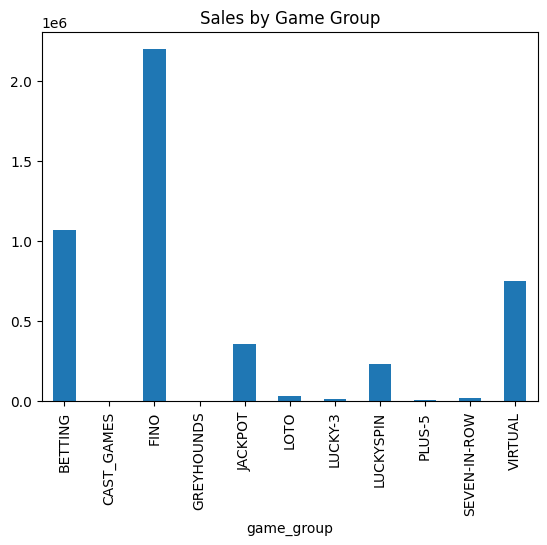

In [11]:
df.groupby("game_group")["sales"].sum().plot(kind="bar")
plt.title("Sales by Game Group")
plt.show()

# 📊 STEP 11 — NEW PLOTS

## 1️⃣ Sales by Category over time

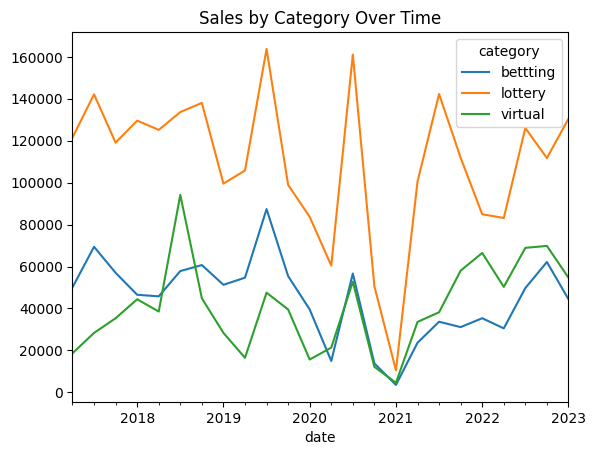

In [12]:
cat_trend = df.groupby(["date","category"])["sales"].sum().unstack()

cat_trend.plot()
plt.title("Sales by Category Over Time")
plt.show()

## 2️⃣ Sales by Game over time

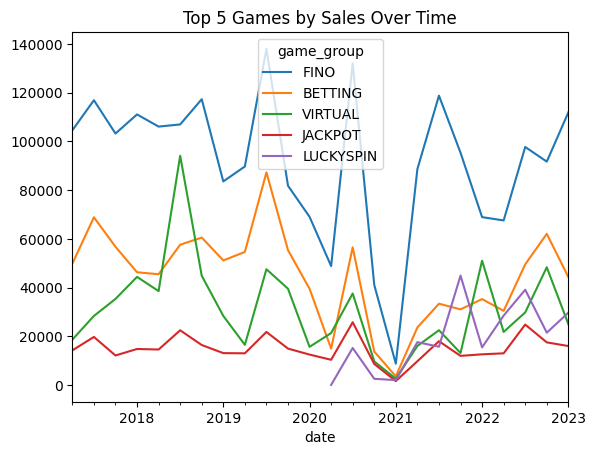

In [13]:
game_trend = df.groupby(["date","game_group"])["sales"].sum().unstack()

# Calculating total sales per game
total_sales_per_game = game_trend.sum().nlargest(5)

# Select only the top 5 games
top_5_games_trend = game_trend[total_sales_per_game.index]

# Visual
top_5_games_trend.plot()
plt.title("Top 5 Games by Sales Over Time")
plt.show()

## 3️⃣ Commission Efficiency

**💰 Convert : sales ➡️ Commission**

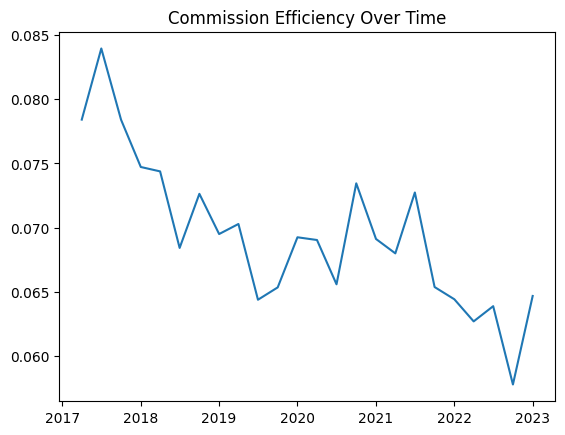

In [14]:
quarterly["efficiency"] = quarterly["final_commission"] / quarterly["sales"]

plt.figure()
plt.plot(quarterly["date"], quarterly["efficiency"])
plt.title("Commission Efficiency Over Time")
plt.show()

**Average Commission Rate by Category**

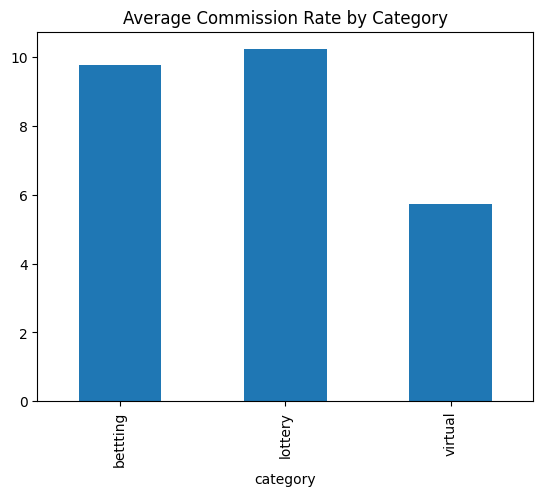

In [15]:
df.groupby("category")["commission_rate_%"].mean().plot(kind="bar")
plt.title("Average Commission Rate by Category")
plt.show()

## 4️⃣ Growth Rate

**% change from quarter to quarter**

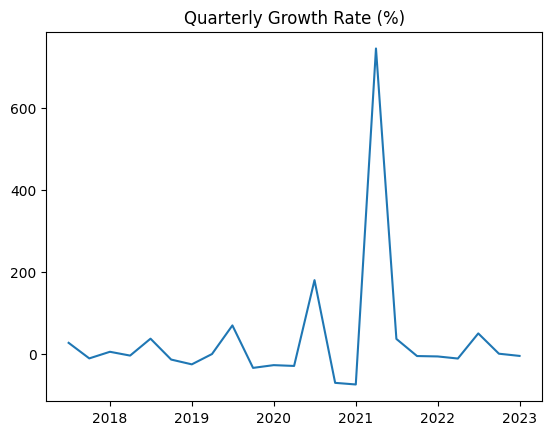

In [16]:
quarterly["growth_rate"] = quarterly["sales"].pct_change() * 100

plt.figure()
plt.plot(quarterly["date"], quarterly["growth_rate"])
plt.title("Quarterly Growth Rate (%)")
plt.show()

# 🔥 FINAL INSIGHTS

## 📊 1. Revenue Concentration (Game Grouping Insight)

- FINO ≈ 2.2M
- BETTING ≈ 1.07M
- VIRTUAL ≈ 0.75M

**✔ Insight:**

- Revenue is highly concentrated in a small number of core product groups, with FINO alone accounting for the largest share of total sales.
- The business relies heavily on lottery-type products, while betting and virtual games act as secondary revenue streams.

## 📉 2. COVID Impact & Recovery (Growth Rate Insight)

- up to -50% off
- after spike up to +750%

**✔ Insight:**

The extreme fluctuation in growth rate around 2020–2021 highlights a severe disruption followed by a sharp recovery, from ≈ -50% to ≈+750%

**✔ Interpretation:**

This pattern is consistent with external shocks such as COVID-19 restrictions, where operations were temporarily halted and then rapidly resumed.

**✔ 🔥 GOLD LINE:**

The business demonstrates high sensitivity to external disruptions but also strong rebound capacity.

## 💰 3. Commission Efficiency 

**From the chart:**

- 2017: ~8.3%
- 2023: ~6.4%
- steady decline

**✔ Core Insight:**

Commission efficiency shows a clear downward trend over time, decreasing from ~8.3% to ~6.4%.

**✔ Business Meaning:**

Despite stable or recovering sales, the business generates less commission per unit of revenue over time.

👉 In simple terms:

**More sales ≠ More profit efficiency**

**✔ Interpretations:**

- change in commission structure

- shift to lower margin products


## 📊 4. Category Performance

**👉 From the totals:**

- Lottery dominates
- Betting & Virtual significantly but secondary

**✔ Insight:**

Lottery products are the backbone of the business, consistently outperforming other categories.

## 📈 5. Volatility & Seasonality

**✔ Insight:**

Sales exhibit significant volatility across quarters, suggesting dependence on external factors rather than stable organic growth.

## 🔝 6. Top Games Analysis

**👉 From the top 5 plot:**

**✔ Insight:**

A small subset of games consistently drives performance, reinforcing the presence of a strong core product portfolio.

**©️ 2026 Periklis Andrianos , 
    MIT LICENSE**